In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import polars as pl
import scienceplots
import seaborn as sns

from qr.utils import *

sns.set_style("whitegrid")
plt.style.use(["science", "grid", "no-latex"])

In [2]:
ticker = "PFE"
base = Path.home() / f"dev_cpp/qr/data/results/{ticker}/hft_strategy"

grid = pl.concat(
    [
        pl.read_parquet(base / "7df5ec40804ebb8e.parquet").with_columns(
            pl.lit(False).alias("strategy_impact")
        ),
        pl.read_parquet(base / "0c3c845f1f234c94.parquet").with_columns(
            pl.lit(True).alias("strategy_impact")
        ),
    ]
)

q_maxes = grid["q_max"].unique().sort().to_numpy()

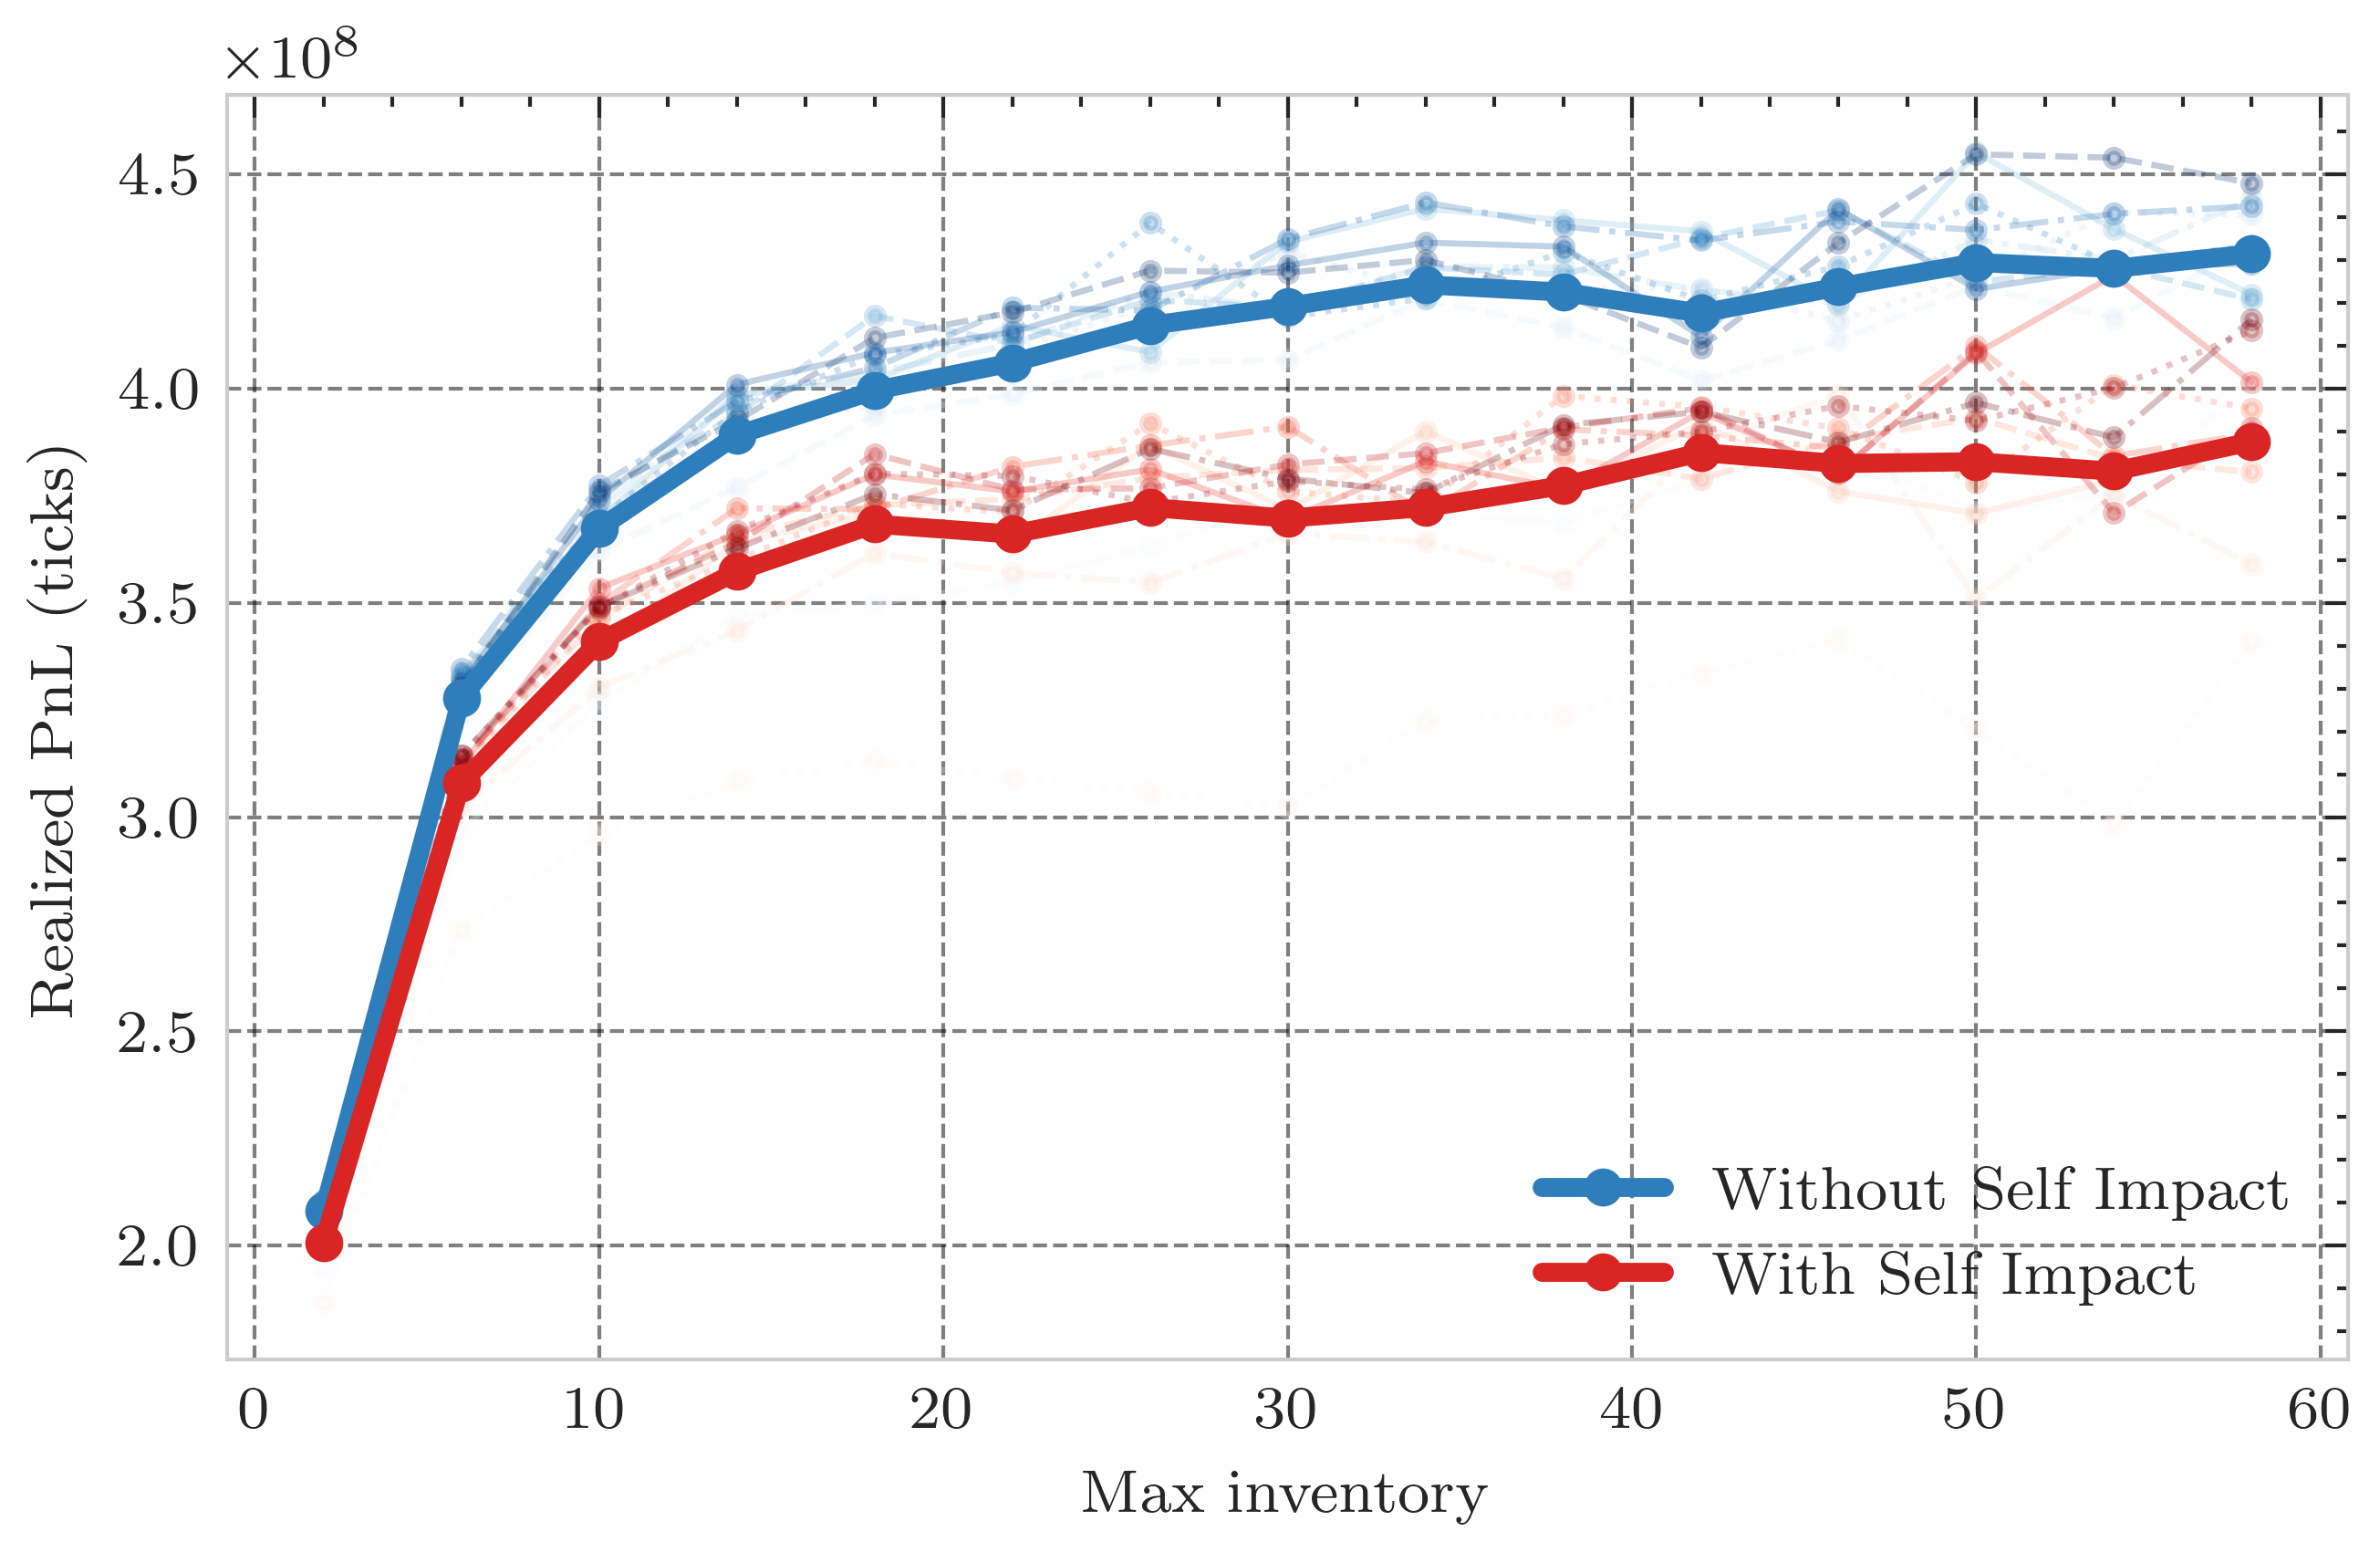

In [3]:
with ieee():
    fig, ax = plt.subplots(figsize=(5, 3))
    fig.patch.set_alpha(0)

    cmap_no = plt.cm.Blues
    cmap_si = plt.cm.Reds
    norm = mcolors.Normalize(vmin=min(q_maxes), vmax=max(q_maxes))

    for si, cmap, label, ls in [
        (False, cmap_no, "Without Self Impact", "-"),
        (True, cmap_si, "With Self Impact", "-"),
    ]:
        for q in q_maxes:
            sub = grid.filter(
                (pl.col("strategy_impact") == si)
                & (pl.col("threshold") == 0.86)
                & (pl.col("q_max") == q)
            ).sort("max_inventory")
            ax.plot(
                sub["max_inventory"],
                sub["realized_pnl"],
                color=cmap(norm(q)),
                alpha=0.25,
                linewidth=0.8,
                marker="o",
                markersize=2,
            )

        avg = (
            grid.filter(
                (pl.col("strategy_impact") == si) & (pl.col("threshold") == 0.86)
            )
            .group_by("max_inventory")
            .agg(pl.col("realized_pnl").mean())
            .sort("max_inventory")
        )

        color = cmap(0.7)
        ax.plot(
            avg["max_inventory"],
            avg["realized_pnl"],
            color=color,
            linewidth=2.5,
            linestyle=ls,
            label=label,
            zorder=5,
            marker="o",
            markersize=4,
        )

    ax.set_xlabel("Max inventory")
    ax.set_ylabel("Realized PnL (ticks)")
    ax.legend()
    fig.savefig("../../paper/hft_pnl_realized_combined_PFE.pdf", bbox_inches="tight")
    plt.show()

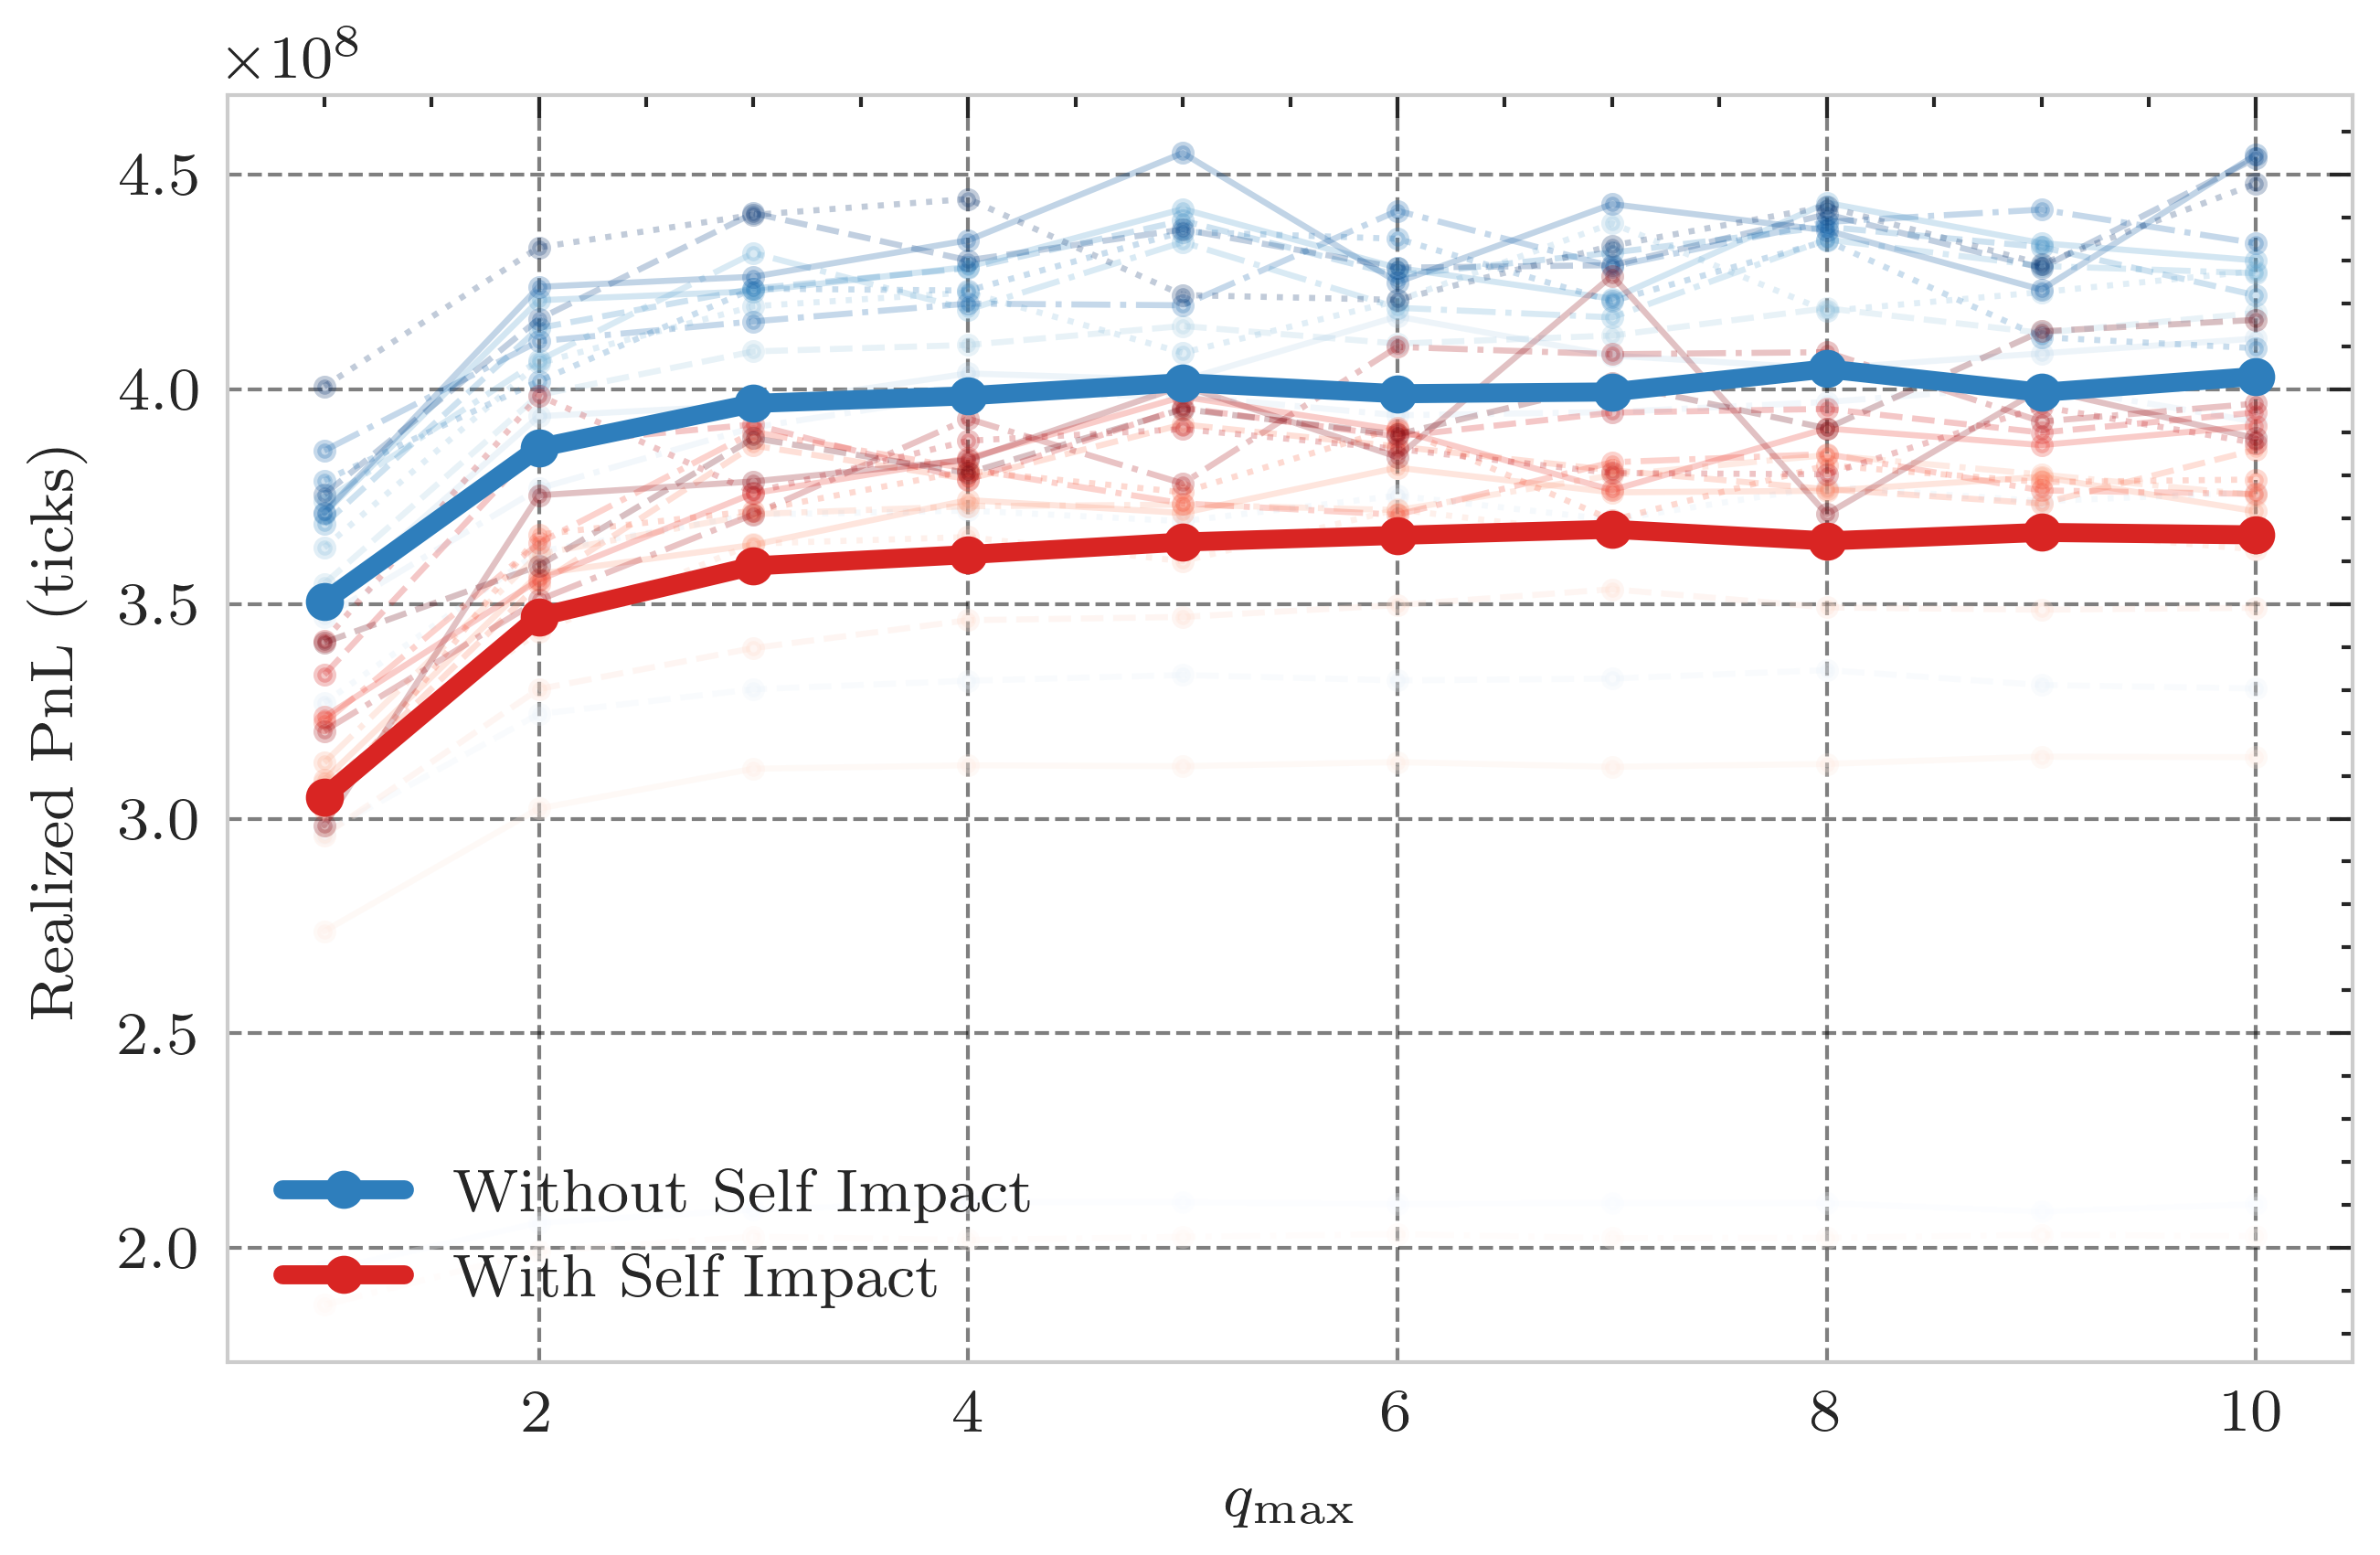

In [4]:
with ieee():
    fig, ax = plt.subplots(figsize=(5, 3))
    fig.patch.set_alpha(0)

    max_invs = sorted(grid["max_inventory"].unique().to_list())
    cmap_no = plt.cm.Blues
    cmap_si = plt.cm.Reds
    norm = mcolors.Normalize(vmin=min(max_invs), vmax=max(max_invs))

    for si, cmap, label, ls in [
        (False, cmap_no, "Without Self Impact", "-"),
        (True, cmap_si, "With Self Impact", "-"),
    ]:
        for inv in max_invs:
            sub = grid.filter(
                (pl.col("strategy_impact") == si)
                & (pl.col("threshold") == 0.86)
                & (pl.col("max_inventory") == inv)
            ).sort("q_max")
            ax.plot(
                sub["q_max"],
                sub["realized_pnl"],
                color=cmap(norm(inv)),
                alpha=0.25,
                linewidth=0.8,
                marker="o",
                markersize=2,
            )

        avg = (
            grid.filter(
                (pl.col("strategy_impact") == si) & (pl.col("threshold") == 0.86)
            )
            .group_by("q_max")
            .agg(pl.col("realized_pnl").mean())
            .sort("q_max")
        )

        color = cmap(0.7)
        ax.plot(
            avg["q_max"],
            avg["realized_pnl"],
            color=color,
            linewidth=2.5,
            linestyle=ls,
            label=label,
            zorder=5,
            marker="o",
            markersize=4,
        )

    ax.set_xlabel(r"$q_{\max}$")
    ax.set_ylabel("Realized PnL (ticks)")
    ax.legend()
    fig.savefig("../../paper/hft_pnl_qmax_combined_PFE.pdf", bbox_inches="tight")
    plt.show()